In [1]:
# %%
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0,efficientnet_b2
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# %%
# ======= Setup =======
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ======= Paths =======
data_csv = "/mnt/d/lding/CLS/mousumiLiuDinner/selected_for_annotation_mt_strcture_20250310_MA.csv"
image_dir = "/mnt/d/lding/CLS/mousumiLiuDinner/set1to5_processed_results/Microtubule_GUV-Liu-20250106T211105Z-001/processed_MT/GUV-MT_obj_png_selected_std15"

# ======= Load CSV and Split =======
df = pd.read_csv(data_csv).dropna(subset=["filename", "label"])
df["label"] = df["label"].astype(str)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)

# ======= Transforms =======
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])
val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])
# %%
# ======= Dataset =======
class CustomDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.data = dataframe.copy()
        self.root_dir = root_dir
        self.transform = transform
        self.label_to_index = {label: idx for idx, label in enumerate(sorted(self.data["label"].unique()))}
        self.data["label"] = self.data["label"].map(self.label_to_index)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.data.iloc[idx]["filename"])
        image = Image.open(img_path).convert("RGB")
        label = self.data.iloc[idx]["label"]
        if self.transform:
            image = self.transform(image)
        return image, label
# %%
train_dataset = CustomDataset(train_df, image_dir, train_transform)
val_dataset = CustomDataset(val_df, image_dir, val_transform)



# %%


Using device: cuda


In [2]:
df

,filename,label
0,1_10 Tau_Tubulin-Date 1-Image10_GUV.TIF_cell02...,Patch
1,1_10 Tau_Tubulin-Date 1-Image3_GUV.TIF_cell03_...,Patch
2,1_10 Tau_Tubulin-Date 1-Image6_GUV.TIF_cell01_...,Network
3,1_10 Tau_Tubulin-Date 1-Image8_GUV.TIF_cell04_...,ZZZ
4,1_10 Tau_Tubulin-Date 1-Image9_GUV.TIF_cell02_...,Network
...,...,...
349,3_10 Tau_Tubulin-Date 5-2 uM tau mt encap guv1...,Patch
350,3_10 Tau_Tubulin-Date 5-2 uM tau mt encap guv8...,Patch
351,3_10 Tau_Tubulin-Date 5-2 uM tau mt encap guv8...,Patch
352,3_10 Tau_Tubulin-Date 5-2 uM tau mt encap guv8...,Patch


In [3]:

from torch.utils.data import WeightedRandomSampler

# Compute sample weights
labels = train_df["label"].map(train_dataset.label_to_index)
class_counts = labels.value_counts().sort_index().values
class_weights = 1. / class_counts
sample_weights = labels.map(lambda x: class_weights[x]).values

sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)


# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)



/home/ldin/anaconda3/envs/pytorch_cuda124/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ldin/anaconda3/envs/pytorch_cuda124/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1: Train Acc: 0.4291, Val Acc: 0.3239
Epoch 2: Train Acc: 0.6135, Val Acc: 0.3099
Epoch 3: Train Acc: 0.6277, Val Acc: 0.3944
Epoch 4: Train Acc: 0.7021, Val Acc: 0.4930
Epoch 5: Train Acc: 0.7482, Val Acc: 0.5493
Epoch 6: Train Acc: 0.7730, Val Acc: 0.5775
Epoch 7: Train Acc: 0.8121, Val Acc: 0.6479
Epoch 8: Train Acc: 0.8050, Val Acc: 0.6338
Epoch 9: Train Acc: 0.8014, Val Acc: 0.7183
Epoch 10: Train Acc: 0.8759, Val Acc: 0.7042
Epoch 11: Train Acc: 0.8546, Val Acc: 0.6761
Epoch 12: Train Acc: 0.8546, Val Acc: 0.6761
Epoch 13: Train Acc: 0.8936, Val Acc: 0.6761
Epoch 14: Train Acc: 0.8617, Val Acc: 0.6901
Epoch 15: Train Acc: 0.8865, Val Acc: 0.6901
Epoch 16: Train Acc: 0.9397, Val Acc: 0.6761
Epoch 17: Train Acc: 0.9043, Val Acc: 0.6901
Epoch 18: Train Acc: 0.9184, Val Acc: 0.6901
Epoch 19: Train Acc: 0.8901, Val Acc: 0.6901
Epoch 20: Train Acc: 0.9149, Val Acc: 0.6901
Epoch 21: Train Acc: 0.9184, Val Acc: 0.6761
Epoch 22: Train Acc: 0.9362, Val Acc: 0.6761
Epoch 23: Train Acc

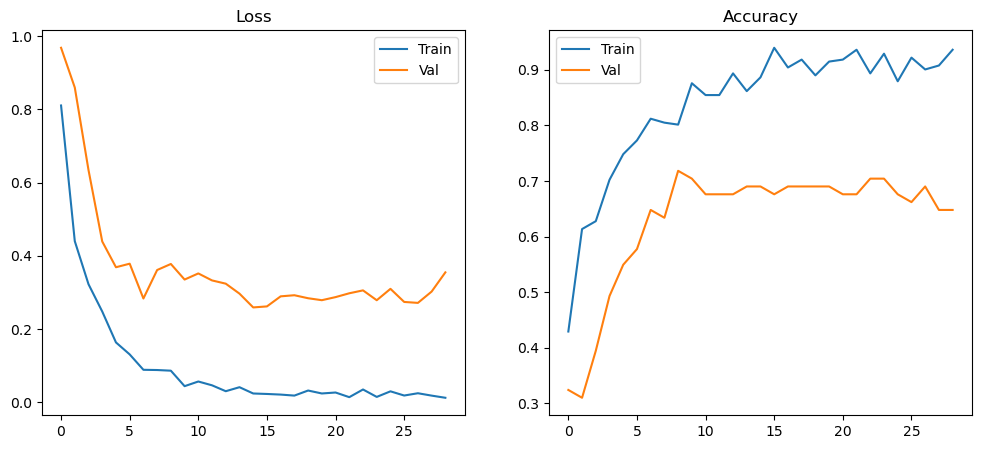

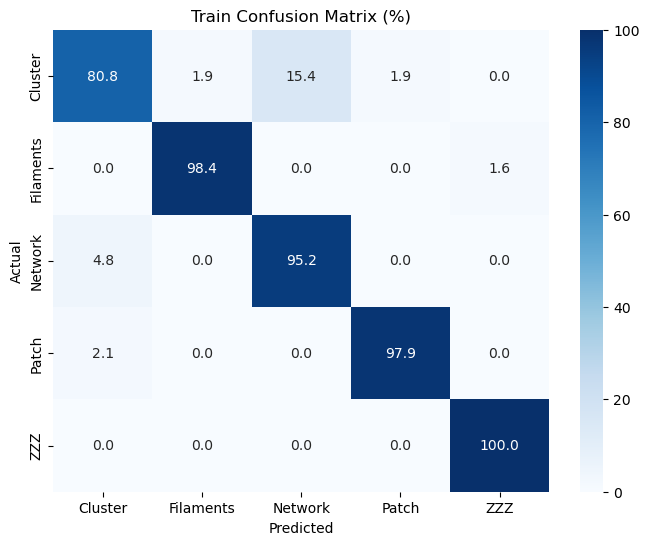

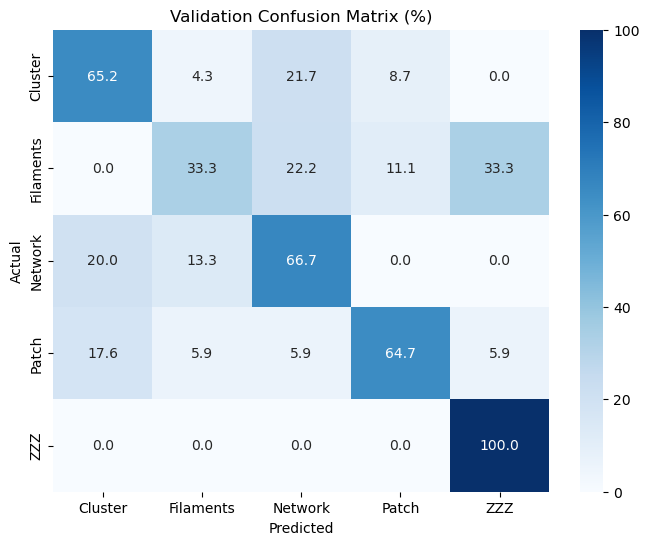

Final model saved.


In [4]:

# %%
# ======= Model =======
model = efficientnet_b0(pretrained=True)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(num_ftrs, len(train_dataset.label_to_index))
)
model = model.to(device)
# %%
# ======= Focal Loss =======
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        return self.alpha * (1 - pt) ** self.gamma * ce_loss

criterion = FocalLoss(alpha=1, gamma=2)

# ======= Optimizer & Scheduler =======
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)
# %%
# ======= Train Function =======
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=100, patience=20):
    best_val_acc = 0
    patience_counter = 0
    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        train_loss, correct_train, total_train = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == y).sum().item()
            total_train += y.size(0)

        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == y).sum().item()
                total_val += y.size(0)

        scheduler.step()

        train_acc = correct_train / total_train
        val_acc = correct_val / total_val
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}: Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping.")
                break

    plot_metrics(train_losses, val_losses, train_accs, val_accs)
# %%
# ======= Plotting =======
def plot_metrics(train_losses, val_losses, train_accs, val_accs):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train")
    plt.plot(val_losses, label="Val")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label="Train")
    plt.plot(val_accs, label="Val")
    plt.title("Accuracy")
    plt.legend()
    plt.show()

# ======= Confusion Matrix =======
def plot_confusion_matrix(loader, name):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, preds = torch.max(outputs, 1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100
    labels = list(train_dataset.label_to_index.keys())
    df_cm = pd.DataFrame(cm_pct, index=labels, columns=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_cm, annot=True, fmt=".1f", cmap="Blues")
    plt.title(f"{name} Confusion Matrix (%)")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()
# %%
# ======= Run Training =======
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=100, patience=20)

# ======= Final Evaluation =======
plot_confusion_matrix(train_loader, "Train")
plot_confusion_matrix(val_loader, "Validation")

# Save final model
torch.save(model.state_dict(), "5classes_finetuned_model_B0_0513A.pth")
print("Final model saved.")